# Three-Qubit Quantum Energy Teleportation -- MISO & SIMO Reproduction

Companion code for **"Three-Qubit Quantum Energy Teleportation Protocol for Significantly
High Energy Efficiency Utilizing Superconducting Qubits."**

This notebook reproduces, from scratch, the two protocols of the paper in their current form:

1. The 3-qubit transverse-field Ising Hamiltonian, its entangled zero-energy ground state, and the closed-form coefficient $M=k/(2h+k+2K)$.
2. The zero-mean-energy constants $c_H,c_V$.
3. **SIMO** (Single-Input Multiple-Output) -- a single sender (Alice) deposits $E_0$; the two **joint receivers** Bob and Charlie reach the ground state of the conditional Hamiltonian $H_\mu$. Every interaction term, including the inter-receiver bond $V_{1,2}$, is retained, giving the honest efficiency $\eta_{\mathrm{SIMO}}=W/E_0\approx 8\%$ to $10\%$.
4. **MISO** (Multiple-Input Single-Output) -- two senders (Alice, Charlie) deposit a combined energy by an entangle-then-measure measurement; Bob extracts it. After removing the part the entangler places directly into Bob's bond, the **net** efficiency is $\eta_{\mathrm{MISO}}=-\langle E_b\rangle/\langle E_S\rangle\approx 34\%$ to $42\%$ (energy-conserving).
5. Comparison with the minimal 2-qubit model (work efficiency $\approx 11.7\%$).
6. Efficiency heatmaps over the $(h,k)$ plane.
7. Hardware-ready Qiskit circuits for both protocols, with shot-based readout of the energy components.

**Conventions.** Qubits $q_0=$ Alice, $q_1=$ Charlie, $q_2=$ Bob (Qiskit little-endian). Exact
sections use $8\times8$ / $4\times4$ NumPy operators; the Qiskit section samples the circuits on Aer.

**Dependencies.** `numpy`, `matplotlib`, `qiskit`, `qiskit-aer`.


## 0. Setup -- operators, ground state, constants

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2)
X  = np.array([[0, 1], [1, 0]], float)
Z  = np.array([[1, 0], [0, -1]], float)
Y  = np.array([[0, -1j], [1j, 0]], complex)

def op(q, M, n=3):
    '''Place 2x2 matrix M on qubit q of an n-qubit register (q0 = least significant).'''
    f = [I2] * n
    f[n - 1 - q] = M
    out = f[0]
    for t in f[1:]:
        out = np.kron(out, t)
    return out

def K_(h, k):                      # characteristic eigenvalue
    return np.sqrt(h*h + h*k + k*k)

def M_(h, k):                      # ground-state coefficient
    return k / (2*h + k + 2*K_(h, k))

def ground_state(h, k):
    '''|g> = (1/N)(|111> - M(|001>+|010>+|100>)),  N = sqrt(1+3 M^2).'''
    M = M_(h, k); N = np.sqrt(1 + 3*M*M)
    g = np.zeros(8); g[[1, 2, 4]] = -M / N; g[7] = 1 / N
    return g

def constants(h, k):
    '''Zero-mean-energy shifts c_H, c_V.'''
    M = M_(h, k)
    return h*(1 - M**2)/(1 + 3*M**2), 2*k*M*(1 - M)/(1 + 3*M**2)

def H_tot(h, k):
    K = K_(h, k)
    return (h*(op(0, Z) + op(1, Z) + op(2, Z))
            + k*(op(0, X)@op(1, X) + op(1, X)@op(2, X) + op(0, X)@op(2, X))
            + (2*K + h - k)*np.eye(8))

print("setup complete")

setup complete


## 1. Ground state is the zero-energy null space

We confirm $H_{\mathrm{tot}}|g\rangle = 0$ with a single vanishing eigenvalue, the closed-form
$M$ matches diagonalization, and every local/semi-local term has zero mean,
$\langle g|H_n|g\rangle=\langle g|V_{i,j}|g\rangle=0$, with $3c_H+3c_V=2K+h-k$.

In [2]:
for (h, k) in [(1, 3), (1, 4), (1.5, 1.0), (2, 8)]:
    H = H_tot(h, k); g = ground_state(h, k); cH, cV = constants(h, k); K = K_(h, k)
    w = np.linalg.eigvalsh(H)
    locs = [g @ (h*op(n, Z) + cH*np.eye(8)) @ g for n in range(3)]
    sems = [g @ (k*op(i, X)@op(j, X) + cV*np.eye(8)) @ g for (i, j) in [(0,1),(1,2),(0,2)]]
    print(f"(h,k)=({h},{k}):  M={M_(h,k):.5f}  E_min={w[0]:+.2e}  <g|H|g>={g@H@g:+.2e}  "
          f"max|<H_n>|={max(abs(x) for x in locs):.1e}  max|<V_ij>|={max(abs(x) for x in sems):.1e}  "
          f"3cH+3cV={3*cH+3*cV:.4f}  2K+h-k={2*K+h-k:.4f}")

(h,k)=(1,3):  M=0.24568  E_min=+1.39e-15  <g|H|g>=+2.04e-16  max|<H_n>|=8.3e-17  max|<V_ij>|=5.6e-17  3cH+3cV=5.2111  2K+h-k=5.2111
(h,k)=(1,4):  M=0.26376  E_min=+1.64e-16  <g|H|g>=-1.18e-16  max|<H_n>|=2.8e-17  max|<V_ij>|=2.2e-16  3cH+3cV=6.1652  2K+h-k=6.1652
(h,k)=(1.5,1.0):  M=0.11963  E_min=-4.65e-16  <g|H|g>=+4.40e-16  max|<H_n>|=1.5e-16  max|<V_ij>|=4.2e-17  3cH+3cV=4.8589  2K+h-k=4.8589
(h,k)=(2,8):  M=0.26376  E_min=+3.29e-16  <g|H|g>=-2.35e-16  max|<H_n>|=5.6e-17  max|<V_ij>|=4.4e-16  3cH+3cV=12.3303  2K+h-k=12.3303


## 2. SIMO -- single sender, two joint receivers

Alice ($q_0$) measures $X_0=\mu$ (probability $\tfrac12$ each), depositing $E_0=c_H$. Because
$X_0$ commutes with every receiver term, no energy is injected into the pair; conditioned on $\mu$
the receivers $(q_1,q_2)$ are governed by the $4\times4$ conditional Hamiltonian

$$H_\mu = \langle\mu|H_{\mathrm{tot}}|\mu\rangle = h(Z_1+Z_2) + kX_1X_2 + \mu k(X_1+X_2) + (2K+h-k)\,\mathbb{I}.$$

Acting jointly they reach $\lambda_{\min}(H_\mu)$, so the extracted work and efficiency are
$$W = E_0 - \sum_{\mu=\pm1} p_\mu\,\lambda_{\min}(H_\mu), \qquad \eta_{\mathrm{SIMO}} = W/E_0.$$
The inter-receiver bond $\langle V_{1,2}\rangle$ turns **positive** at the joint optimum and is fully
included in the balance.

In [3]:
def simo(h, k):
    '''SIMO joint-receiver work and per-bond energies (exact).'''
    K = K_(h, k); cH, cV = constants(h, k); E0 = cH
    X1, X2 = op(0, X, 2), op(1, X, 2)
    Z1, Z2 = op(0, Z, 2), op(1, Z, 2); I4 = np.eye(4)
    H2  = h*Z2 + cH*I4
    V12 = k*(X1 @ X2) + cV*I4
    lam = V02a = V12a = H2a = 0.0
    for mu in (1, -1):
        Hmu = h*(Z1 + Z2) + k*(mu*X1 + X1 @ X2 + mu*X2) + (2*K + h - k)*I4
        w, V = np.linalg.eigh(Hmu); gs = V[:, 0]
        lam  += 0.5*w[0]
        V02a += 0.5*np.vdot(gs, (k*mu*X2 + cV*I4) @ gs).real   # Alice-Bob bond after X0=mu
        V12a += 0.5*np.vdot(gs, V12 @ gs).real                 # inter-receiver bond
        H2a  += 0.5*np.vdot(gs, H2 @ gs).real
    W = E0 - lam
    return dict(E0=E0, W=W, eta=W/E0*100, V02=V02a, V12=V12a, H2=H2a)

print(f"{'(h,k)':>7} | {'E0':>6} | {'W':>6} | {'eta_SIMO':>8} | {'V02':>7} | {'V12':>7} | {'H2':>7}")
for (h, k) in [(1, 3), (1, 4)]:
    r = simo(h, k)
    print(f"{('('+str(h)+','+str(k)+')'):>7} | {r['E0']:6.3f} | {r['W']:6.3f} | {r['eta']:7.2f}% "
          f"| {r['V02']:+7.3f} | {r['V12']:+7.3f} | {r['H2']:+7.3f}")

  (h,k) |     E0 |      W | eta_SIMO |     V02 |     V12 |      H2
  (1,3) |  0.796 |  0.075 |    9.40% |  -0.455 |  +0.803 |  +0.016
  (1,4) |  0.770 |  0.077 |   10.03% |  -0.614 |  +1.138 |  +0.006


## 3. MISO -- two combined senders, single receiver

Alice and Charlie entangle with a CNOT$(0\!\to\!1)$ and are jointly measured in the $X$ basis,
depositing a combined energy $\langle E_{AC}\rangle$. The entangler places part of this,
$\langle E_b^{(0)}\rangle$, directly into Bob's bond before he acts, so we report the **net**
efficiency against the senders' own deposit:
$$\langle E_S\rangle = \langle E_{AC}\rangle - \langle E_b^{(0)}\rangle, \qquad
\eta_{\mathrm{MISO}} = \frac{-\langle E_b\rangle}{\langle E_S\rangle},$$
where $\langle E_b\rangle<0$ is Bob's region after his optimal conditional rotation $R_Y$.

In [4]:
def cnot01():
    C = np.zeros((8, 8))
    for s in range(8):
        q0, q1, q2 = s & 1, (s >> 1) & 1, (s >> 2) & 1
        if q0: q1 ^= 1
        C[q0 | (q1 << 1) | (q2 << 2), s] = 1
    return C

def miso(h, k, ngrid=4001):
    '''MISO combined deposit, optimal Bob rotation, and net efficiency (exact).'''
    g = ground_state(h, k); H = H_tot(h, k); cH, cV = constants(h, k)
    Cg = cnot01() @ g; I8 = np.eye(8); Yb = op(2, Y)
    B = (h*op(2, Z) + cH*I8) + (k*op(0, X)@op(2, X) + cV*I8) + (k*op(1, X)@op(2, X) + cV*I8)  # Bob region
    S = (h*op(0, Z) + cH*I8) + (h*op(1, Z) + cH*I8) + (k*op(0, X)@op(1, X) + cV*I8)            # sender region
    ths = np.linspace(0, 2*np.pi, ngrid)
    US = [np.cos(t/2)*I8 - 1j*np.sin(t/2)*Yb for t in ths]
    EAC = ES = Eb0 = Eb = 0.0
    for mu0 in (1, -1):
        for mu1 in (1, -1):
            psi = ((I8 + mu1*op(1, X))/2) @ ((I8 + mu0*op(0, X))/2) @ Cg
            p = np.vdot(psi, psi).real
            if p < 1e-12: continue
            psin = psi/np.sqrt(p)
            EAC += p*np.vdot(psin, H @ psin).real
            ES  += p*np.vdot(psin, S @ psin).real
            Eb0 += p*np.vdot(psin, B @ psin).real
            Eb  += p*min(np.vdot(U @ psin, B @ (U @ psin)).real for U in US)
    return dict(EAC=EAC, ES=ES, Eb0=Eb0, Eb=Eb, eta=-Eb/ES*100)

print(f"{'(h,k)':>7} | {'E_AC':>6} | {'E_S':>6} | {'E_b0':>7} | {'E_b':>7} | {'eta_MISO':>8}")
for (h, k) in [(1, 3), (1, 4)]:
    r = miso(h, k)
    print(f"{('('+str(h)+','+str(k)+')'):>7} | {r['EAC']:6.3f} | {r['ES']:6.3f} | {r['Eb0']:+7.3f} "
          f"| {r['Eb']:+7.3f} | {r['eta']:7.1f}%")
print("\\ncheck  E_AC = E_S + E_b0 :", [round(miso(h,k)['EAC'] - miso(h,k)['ES'] - miso(h,k)['Eb0'], 6) for (h,k) in [(1,3),(1,4)]])

  (h,k) |   E_AC |    E_S |    E_b0 |     E_b | eta_MISO
  (1,3) |  3.474 |  2.533 |  +0.941 |  -0.863 |    34.1%
  (1,4) |  4.110 |  2.825 |  +1.285 |  -1.191 |    42.2%


\ncheck  E_AC = E_S + E_b0 : [np.float64(-0.0), np.float64(0.0)]


## 4. Minimal 2-qubit model -- work efficiency $\approx 11.7\%$

Hotta's two-qubit QET at $(h,k)=(1.5,1)$: Alice deposits $E_A=h^2/\sqrt{h^2+k^2}$ and Bob extracts
work $W$ by a conditional $R_Y$. The work efficiency $W/E_A$ is the benchmark the 3-qubit protocols
are compared against.

In [5]:
def twoq(h=1.5, k=1.0, ngrid=8001):
    r = np.sqrt(h*h + k*k); I4 = np.eye(4); Yb = op(1, Y, 2)
    g = np.array([np.sqrt(1 - h/r)/np.sqrt(2), 0, 0, -np.sqrt(1 + h/r)/np.sqrt(2)])
    region = (h*op(1, Z, 2) + h*h/r*I4) + (2*k*op(0, X, 2)@op(1, X, 2) + 2*k*k/r*I4)
    E_A = h*h/r
    ths = np.linspace(0, 2*np.pi, ngrid)
    W = 0.0
    for mu in (1, -1):
        psi = ((I4 + mu*op(0, X, 2))/2) @ g; p = np.vdot(psi, psi).real; psin = psi/np.sqrt(p)
        best = min(np.vdot((np.cos(t/2)*I4 - 1j*np.sin(t/2)*Yb) @ psin,
                           region @ ((np.cos(t/2)*I4 - 1j*np.sin(t/2)*Yb) @ psin)).real for t in ths)
        W += p*(-best)
    return E_A, W, W/E_A*100

E_A, W2, eta2 = twoq()
print(f"2-qubit (h,k)=(1.5,1):  E_A={E_A:.4f}  W={W2:.4f}  eta=W/E_A={eta2:.1f}%  (paper rounds to 11.7%)")

2-qubit (h,k)=(1.5,1):  E_A=1.2481  W=0.1425  eta=W/E_A=11.4%  (paper rounds to 11.7%)


## 5. Efficiency heatmaps over the $(h,k)$ plane

Both efficiencies depend only on the ratio $k/h$ and rise monotonically with it. SIMO reaches
$\sim 8\%$ to $10\%$; MISO (net) reaches $\sim 34\%$ to $42\%$ in the regime $k/h=3$ to $4$.

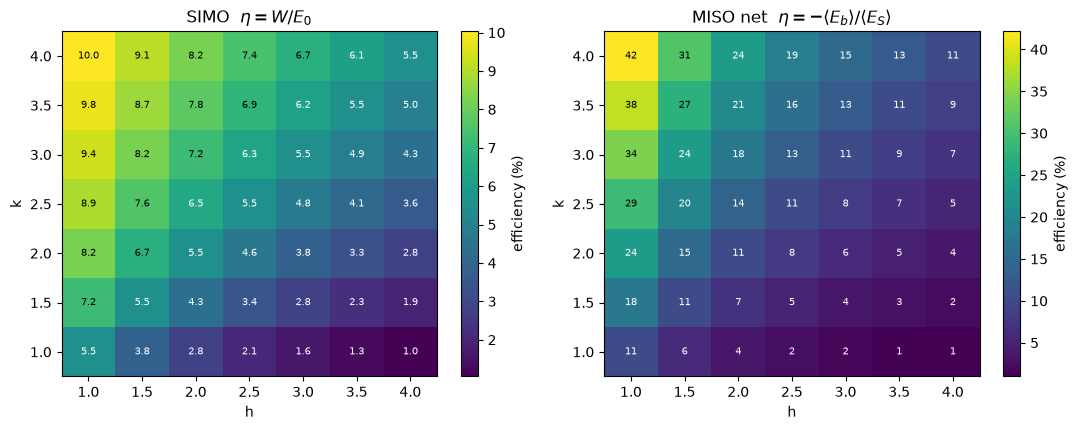

SIMO range 1.0-10.0 %   MISO range 1-42 %


In [6]:
import matplotlib
import matplotlib.pyplot as plt

hs = np.arange(1, 4.01, 0.5); ks = np.arange(1, 4.01, 0.5)
I8 = np.eye(8); Yb = op(2, Y)
THG = np.linspace(0, 2*np.pi, 600)
USG = [np.cos(t/2)*I8 - 1j*np.sin(t/2)*Yb for t in THG]

def miso_eta_fast(h, k):
    g = ground_state(h, k); H = H_tot(h, k); cH, cV = constants(h, k); Cg = cnot01() @ g
    B = (h*op(2, Z)+cH*I8) + (k*op(0, X)@op(2, X)+cV*I8) + (k*op(1, X)@op(2, X)+cV*I8)
    S = (h*op(0, Z)+cH*I8) + (h*op(1, Z)+cH*I8) + (k*op(0, X)@op(1, X)+cV*I8)
    ES = Eb = 0.0
    for mu0 in (1, -1):
        for mu1 in (1, -1):
            psi = ((I8+mu1*op(1, X))/2) @ ((I8+mu0*op(0, X))/2) @ Cg; p = np.vdot(psi, psi).real
            if p < 1e-12: continue
            psin = psi/np.sqrt(p); ES += p*np.vdot(psin, S@psin).real
            Eb += p*min(np.vdot(U@psin, B@(U@psin)).real for U in USG)
    return -Eb/ES*100

MG = np.array([[miso_eta_fast(h, k) for h in hs] for k in ks])
SG = np.array([[simo(h, k)['eta']   for h in hs] for k in ks])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, grid, title, fmt in [(axes[0], SG, "SIMO  $\\eta=W/E_0$", "{:.1f}"),
                             (axes[1], MG, "MISO net  $\\eta=-\\langle E_b\\rangle/\\langle E_S\\rangle$", "{:.0f}")]:
    ext = [hs[0]-0.25, hs[-1]+0.25, ks[0]-0.25, ks[-1]+0.25]
    im = ax.imshow(grid, origin="lower", aspect="auto", extent=ext, cmap="viridis")
    vmin, vmax = grid.min(), grid.max()
    for i, kk in enumerate(ks):
        for j, hh in enumerate(hs):
            ax.text(hh, kk, fmt.format(grid[i, j]), ha="center", va="center", fontsize=7,
                    color="white" if grid[i, j] < vmin + 0.62*(vmax-vmin) else "black")
    ax.set_xlabel("h"); ax.set_ylabel("k"); ax.set_title(title)
    ax.set_xticks(hs); ax.set_yticks(ks); fig.colorbar(im, ax=ax, label="efficiency (%)")
fig.tight_layout(); plt.show()
print("SIMO range %.1f-%.1f %%   MISO range %.0f-%.0f %%" % (SG.min(), SG.max(), MG.min(), MG.max()))

## 6. Qiskit circuits and shot-based readout

We now build the hardware circuits and estimate the energy components from measurement shots on the
Aer simulator, confirming they reproduce the exact values above.

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
sim = AerSimulator()
SHOTS = 200000
print("qiskit ready")

qiskit ready


### 6a. MISO circuit

CNOT$(0\!\to\!1)$, Hadamards and measurements on the two senders, then an outcome-conditioned
$R_Y$ on Bob. The optimal angle for each outcome pair is taken from the exact analysis above.

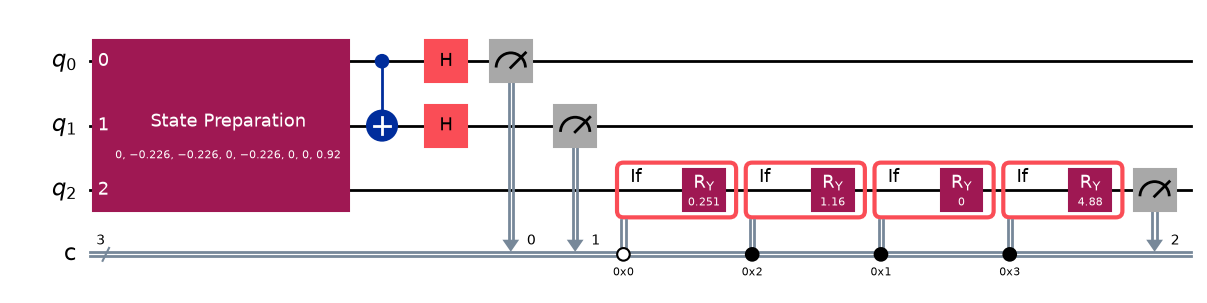

In [8]:
def miso_angles(h, k, ngrid=2001):
    g = ground_state(h, k); cH, cV = constants(h, k); Cg = cnot01() @ g
    I8 = np.eye(8); Yb = op(2, Y)
    B = (h*op(2, Z)+cH*I8) + (k*op(0, X)@op(2, X)+cV*I8) + (k*op(1, X)@op(2, X)+cV*I8)
    ths = np.linspace(0, 2*np.pi, ngrid); ang = {}
    for mu0 in (1, -1):
        for mu1 in (1, -1):
            psi = ((I8+mu1*op(1, X))/2) @ ((I8+mu0*op(0, X))/2) @ Cg; psin = psi/np.linalg.norm(psi)
            es = [np.vdot((np.cos(t/2)*I8-1j*np.sin(t/2)*Yb)@psin,
                          B@((np.cos(t/2)*I8-1j*np.sin(t/2)*Yb)@psin)).real for t in ths]
            ang[(mu0, mu1)] = ths[int(np.argmin(es))]
    return ang

def build_miso(h, k, xbasis=False):
    ang = miso_angles(h, k)
    qr = QuantumRegister(3, "q"); cr = ClassicalRegister(3, "c"); qc = QuantumCircuit(qr, cr)
    qc.prepare_state(ground_state(h, k), [0, 1, 2])
    qc.cx(0, 1); qc.h(0); qc.h(1)
    qc.measure(0, 0); qc.measure(1, 1)
    for c0 in (0, 1):
        for c1 in (0, 1):
            with qc.if_test((cr, c0 + 2*c1)):
                qc.ry(ang[(1 - 2*c0, 1 - 2*c1)], 2)
    if xbasis:
        qc.h(2)
    qc.measure(2, 2)
    return qc

build_miso(1, 3).draw("mpl", fold=-1)

In [9]:
def miso_shots(h, k, shots=SHOTS):
    '''Estimate Bob's region <E_b>, sender region <E_S> and net eta from shots.'''
    cH, cV = constants(h, k)
    def counts(xb):
        qc = transpile(build_miso(h, k, xbasis=xb), sim)
        return sim.run(qc, shots=shots, seed_simulator=11).result().get_counts()
    cz, cx = counts(False), counts(True)   # bitstrings 'c2 c1 c0'
    def exp(cnts, f):
        tot = sum(cnts.values()); s = 0.0
        for bs, n in cnts.items():
            c2, c1, c0 = int(bs[0]), int(bs[1]), int(bs[2]); s += n*f(c0, c1, c2)
        return s/tot
    Z2  = exp(cz, lambda c0, c1, c2: 1 - 2*c2)
    X0X2 = exp(cx, lambda c0, c1, c2: (1 - 2*c0)*(1 - 2*c2))
    X1X2 = exp(cx, lambda c0, c1, c2: (1 - 2*c1)*(1 - 2*c2))
    X0X1 = exp(cx, lambda c0, c1, c2: (1 - 2*c0)*(1 - 2*c1))
    H2 = h*Z2 + cH
    V02 = k*X0X2 + cV
    V12 = k*X1X2 + cV
    Eb = H2 + V02 + V12
    ES = 2*cH + (k*X0X1 + cV)            # <H0>+<H1>=2cH (X eigenstates), <V01>=k<X0X1>+cV
    return dict(H2=H2, V02=V02, V12=V12, Eb=Eb, ES=ES, eta=-Eb/ES*100)

print(f"{'(h,k)':>7} | {'eta_MISO (shots)':>17} | {'eta_MISO (exact)':>17}")
for (h, k) in [(1, 3), (1, 4)]:
    print(f"{('('+str(h)+','+str(k)+')'):>7} | {miso_shots(h,k)['eta']:16.1f}% | {miso(h,k)['eta']:16.1f}%")

  (h,k) |  eta_MISO (shots) |  eta_MISO (exact)


  (1,3) |             33.9% |             34.1%


  (1,4) |             41.9% |             42.2%


### 6b. SIMO circuit

Alice measures $X_0$; conditioned on her single outcome, the joint receivers apply a two-qubit
unitary $U_{BC}(\mu)$ that maps their conditional state onto the ground state of $H_\mu$. The shot
readout reconstructs every receiver term, including $V_{1,2}$, and the work $W$.

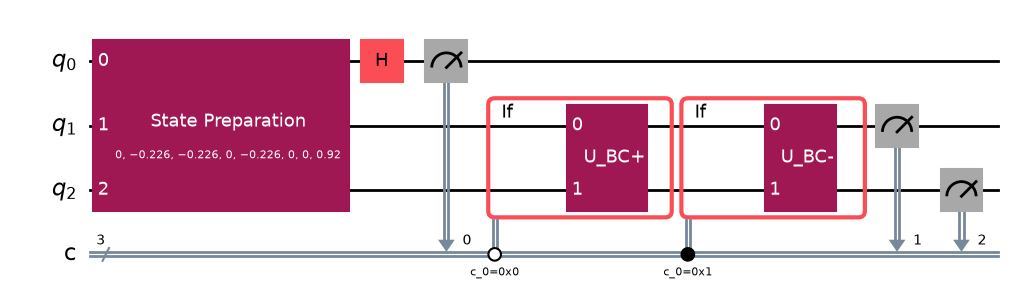

In [10]:
def psi_mu(h, k, mu):
    '''Conditional receiver state on (q1,q2) after Alice's outcome mu; index = q1 + 2 q2.'''
    sv = ground_state(h, k); out = np.zeros(4)
    for s in range(8):
        q0, q1, q2 = s & 1, (s >> 1) & 1, (s >> 2) & 1
        out[q1 + 2*q2] += ((1.0 if q0 == 0 else mu)/np.sqrt(2))*sv[s]
    return out/np.linalg.norm(out)

def U_BC(h, k, mu):
    '''Real orthogonal U with U|psi_mu> = |G_mu>, ground state of the 4x4 H_mu.'''
    K = K_(h, k); X1, X2 = op(0, X, 2), op(1, X, 2); Z1, Z2 = op(0, Z, 2), op(1, Z, 2); I4 = np.eye(4)
    Hmu = h*(Z1 + Z2) + k*(mu*X1 + X1 @ X2 + mu*X2) + (2*K + h - k)*I4
    a = psi_mu(h, k, mu); b = np.linalg.eigh(Hmu)[1][:, 0]
    if np.dot(a, b) < 0: b = -b
    c = float(np.dot(a, b)); G = np.outer(b, a) - np.outer(a, b)
    return I4 + G + G @ G/(1 + c)

def build_simo(h, k, xbasis=False):
    qr = QuantumRegister(3, "q"); cr = ClassicalRegister(3, "c"); qc = QuantumCircuit(qr, cr)
    qc.prepare_state(ground_state(h, k), [0, 1, 2])
    qc.h(0); qc.measure(0, 0)
    with qc.if_test((cr[0], 0)):
        qc.append(UnitaryGate(U_BC(h, k, +1), label="U_BC+"), [1, 2])
    with qc.if_test((cr[0], 1)):
        qc.append(UnitaryGate(U_BC(h, k, -1), label="U_BC-"), [1, 2])
    if xbasis:
        qc.h(1); qc.h(2)
    qc.measure(1, 1); qc.measure(2, 2)
    return qc

build_simo(1, 3).draw("mpl", fold=-1)

In [11]:
def simo_shots(h, k, shots=SHOTS):
    '''Estimate W and eta_SIMO from shots (E0 minus the receiver-region energy reached).'''
    cH, cV = constants(h, k); E0 = cH
    def counts(xb):
        qc = transpile(build_simo(h, k, xbasis=xb), sim)
        return sim.run(qc, shots=shots, seed_simulator=7).result().get_counts()
    cz, cx = counts(False), counts(True)
    def exp(cnts, f):
        tot = sum(cnts.values()); s = 0.0
        for bs, n in cnts.items():
            c2, c1, c0 = int(bs[0]), int(bs[1]), int(bs[2]); s += n*f(c0, c1, c2)
        return s/tot
    Z1 = exp(cz, lambda c0, c1, c2: 1 - 2*c1); Z2 = exp(cz, lambda c0, c1, c2: 1 - 2*c2)
    X0X1 = exp(cx, lambda c0, c1, c2: (1 - 2*c0)*(1 - 2*c1))
    X0X2 = exp(cx, lambda c0, c1, c2: (1 - 2*c0)*(1 - 2*c2))
    X1X2 = exp(cx, lambda c0, c1, c2: (1 - 2*c1)*(1 - 2*c2))
    H1 = h*Z1 + cH; H2 = h*Z2 + cH
    V01 = k*X0X1 + cV; V02 = k*X0X2 + cV; V12 = k*X1X2 + cV
    W = -(H1 + H2 + V01 + V02 + V12)      # = E0 - sum_mu p_mu lambda_min(H_mu)
    return dict(H2=H2, V02=V02, V12=V12, W=W, eta=W/E0*100)

print(f"{'(h,k)':>7} | {'eta_SIMO (shots)':>17} | {'eta_SIMO (exact)':>17}")
for (h, k) in [(1, 3), (1, 4)]:
    print(f"{('('+str(h)+','+str(k)+')'):>7} | {simo_shots(h,k)['eta']:16.2f}% | {simo(h,k)['eta']:16.2f}%")

  (h,k) |  eta_SIMO (shots) |  eta_SIMO (exact)


  (1,3) |             9.70% |             9.40%


  (1,4) |            10.42% |            10.03%


## 7. Summary

| Protocol | Configuration | Efficiency definition | $(1,3)$ | $(1,4)$ |
|---|---|---|---|---|
| **SIMO** | 1 sender, 2 joint receivers | $\eta=W/E_0$ (all terms incl. $V_{1,2}$) | $\approx 9.4\%$ | $\approx 10.0\%$ |
| **MISO** | 2 senders, 1 receiver | $\eta=-\langle E_b\rangle/\langle E_S\rangle$ (net) | $\approx 34.1\%$ | $\approx 42.2\%$ |
| 2-qubit | minimal model | $\eta=W/E_A$ | \multicolumn{2}{c}{$\approx 11.7\%$} |

SIMO is honest (every interaction term, including the positive inter-receiver bond, is retained) and
comparable to the two-qubit benchmark; MISO is the higher, energy-conserving net figure. All shot
estimates above reproduce the exact statevector results.
